## Predict the wine quality

### Imports

#### Libraries

In [1]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


### Data


In [2]:
df = pd.read_csv('../DataBases/winequality/winequality.csv')

#### Variables

- Volatile Acidity
- Citric Acid
- Residual Sugar
- Chlorides
- Free Sulfur Dioxide
- Total Sulfur Dioxide
- Density
- pH
- Sulphates
- Alcohol
- Citric Acid with null cells
- Different Decimal numbers on Residual Sugar, Volatile acidity, Chlorides, FSD, TSD, Density, pH, and alcohol


### EDA

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.1,0.875,0.05,5.7,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,3,red
1,10.3,0.170,0.47,1.4,0.037,5.0,33.0,0.99390,2.89,0.28,9.6,3,white
2,5.8,0.240,0.44,3.5,0.029,5.0,109.0,0.99130,3.53,0.43,11.7,3,white
3,6.9,0.390,0.40,4.6,0.022,5.0,19.0,0.99150,3.31,0.37,12.6,3,white
4,7.6,0.480,0.37,1.2,0.034,5.0,57.0,0.99256,3.05,0.54,10.4,3,white


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6492 entries, 0 to 6491
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6492 non-null   float64
 1   volatile acidity      6492 non-null   float64
 2   citric acid           6492 non-null   float64
 3   residual sugar        6492 non-null   float64
 4   chlorides             6492 non-null   float64
 5   free sulfur dioxide   6492 non-null   float64
 6   total sulfur dioxide  6492 non-null   float64
 7   density               6492 non-null   float64
 8   pH                    6492 non-null   float64
 9   sulphates             6492 non-null   float64
 10  alcohol               6492 non-null   float64
 11  quality               6492 non-null   int64  
 12  type                  6492 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 659.5+ KB


### 
- No missing values
- Citric Acid needs enconding

In [15]:
df.describe().T.style.background_gradient(cmap='Blues') # Tabela transpsota com cor

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6492.000000,7.215149,1.296691,3.800000,6.400000,7.000000,7.700000,15.900000
volatile acidity,6492.000000,0.339698,0.164690,0.080000,0.230000,0.290000,0.400000,1.580000
citric acid,6492.000000,0.318581,0.145348,0.000000,0.250000,0.310000,0.390000,1.660000
residual sugar,6492.000000,5.444254,4.758579,0.600000,1.800000,3.000000,8.100000,65.800000
chlorides,6492.000000,0.056056,0.035038,0.009000,0.038000,0.047000,0.065000,0.611000
free sulfur dioxide,6492.000000,30.523105,17.752926,1.000000,17.000000,29.000000,41.000000,289.000000
total sulfur dioxide,6492.000000,115.744378,56.541478,6.000000,77.000000,118.000000,156.000000,440.000000
density,6492.000000,0.994699,0.002997,0.987110,0.992340,0.994890,0.996990,1.038980
pH,6492.000000,3.218432,0.160817,2.720000,3.110000,3.210000,3.320000,4.010000
sulphates,6492.000000,0.531319,0.148834,0.220000,0.430000,0.510000,0.600000,2.000000


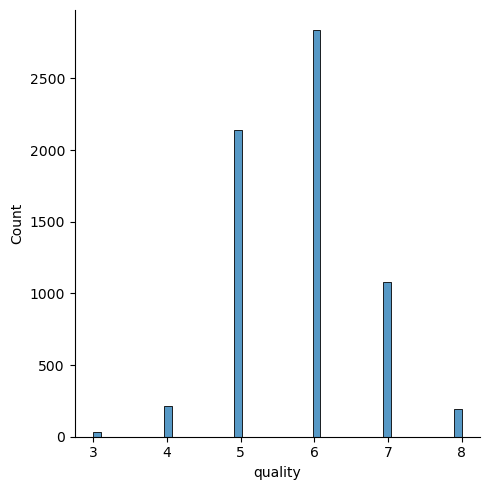

In [9]:
sns.displot(df['quality']) # Distribuição da qualidade do vinho

In [18]:
df.isnull().sum() # Verificando valores nulos

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [19]:
df.nunique() # Verificando valores únicos

fixed acidity           106
volatile acidity        187
citric acid              89
residual sugar          316
chlorides               214
free sulfur dioxide     135
total sulfur dioxide    276
density                 996
pH                      108
sulphates               111
alcohol                 111
quality                   6
type                      2
dtype: int64

#### Can enconde type

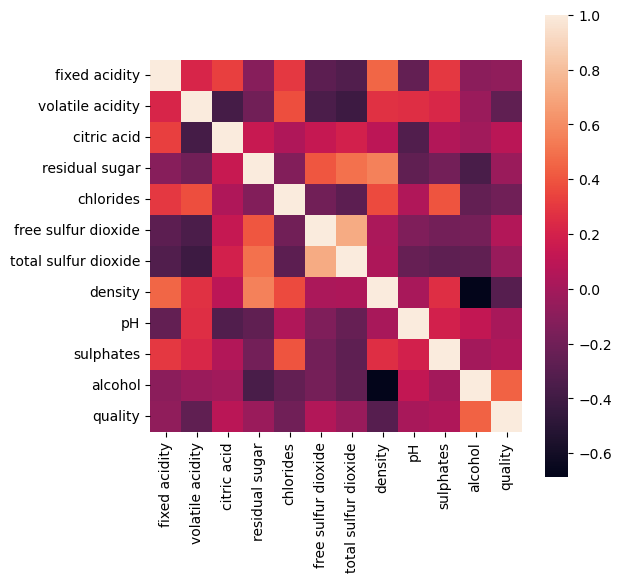

In [20]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True), square=True)
plt.show()

#### Only ""good"" correlation that we can find is alcohol with quality

<Figure size 600x600 with 0 Axes>

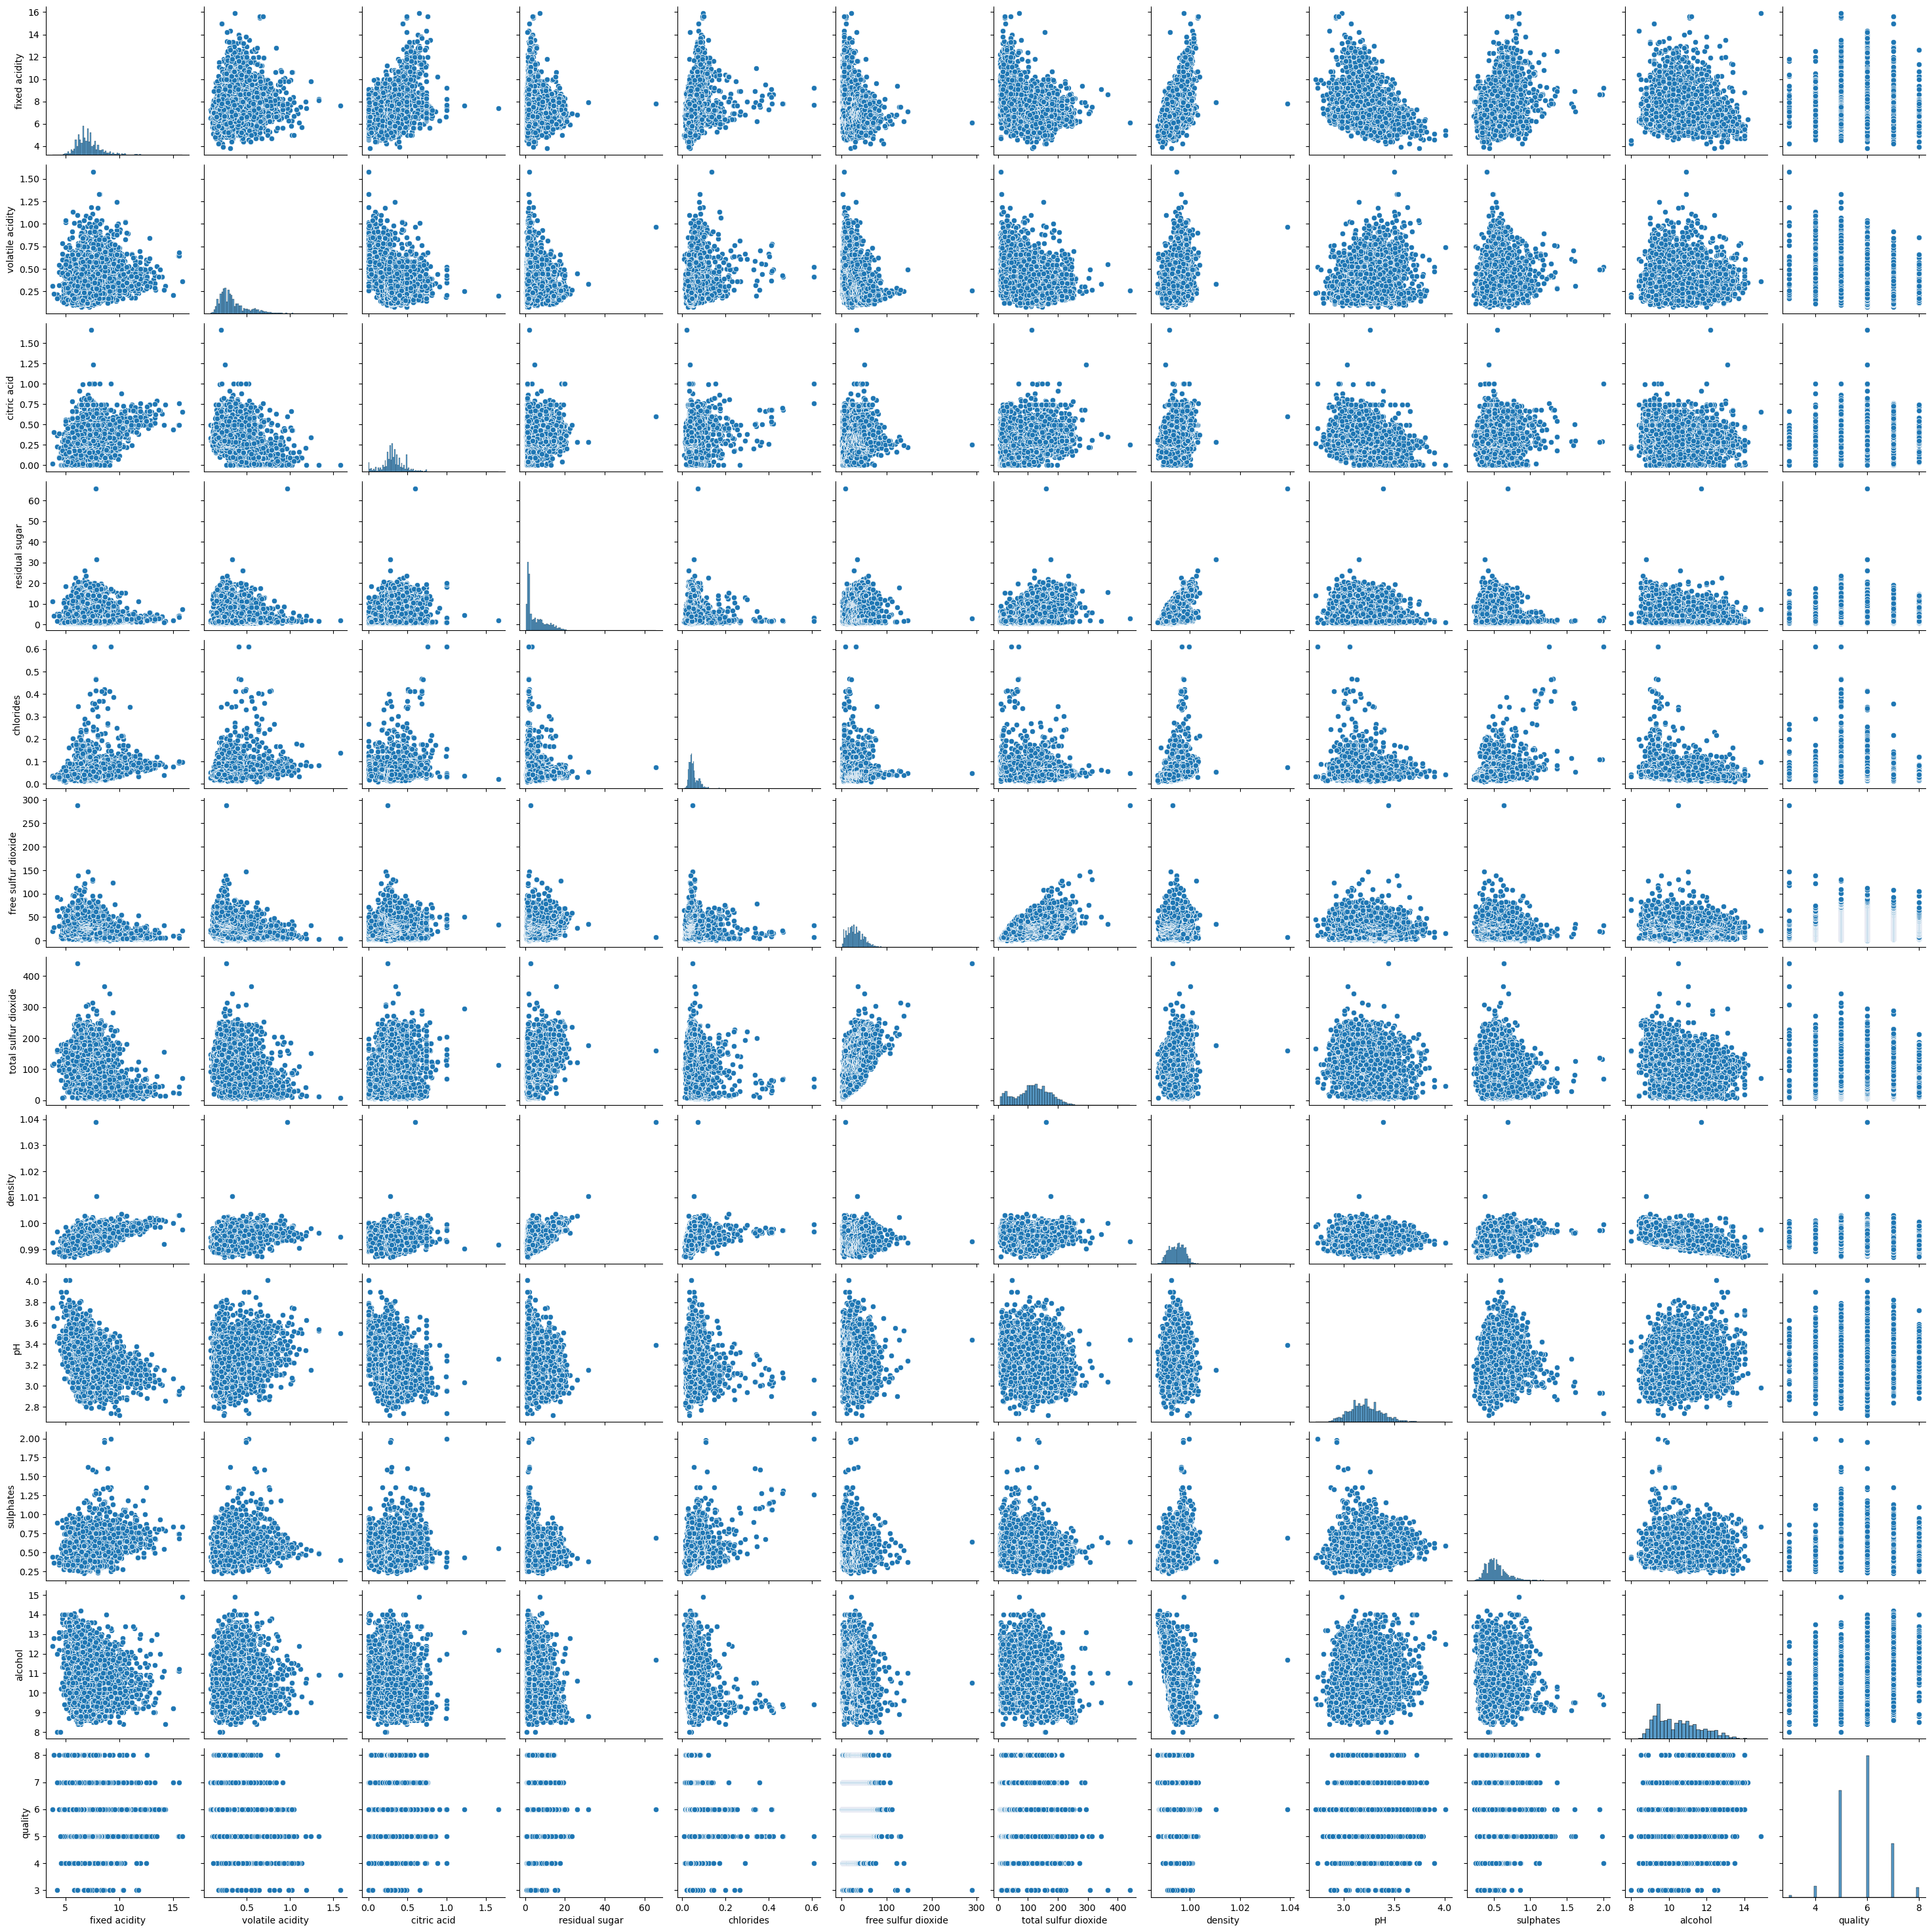

In [22]:
plt.figure(figsize = (6,6))
sns.pairplot(df)
plt.show()

In [32]:
typeCount = df['type'].value_counts()
typeCount

type
white    4893
red      1599
Name: count, dtype: int64

In [33]:
import xgboost as xgb 

In [34]:
xgb_rf_c = xgb.XGBRFClassifier(random_state=24)

xgb_rf_c.fit(X_train, y_train)

xgb_pred = xgb_rf_c.predict(X_test)

print_evaluate("XGB", y_test, xgb_pred)

NameError: name 'X_train' is not defined